# 09 · Neural Models, Robustness, and Fine-Grained Intent Classification

The previous notebooks focused primarily on traditional machine learning approaches and system-level evaluation. This notebook explores whether a simple neural classifier can provide additional benefits and examines model behaviour under more challenging conditions.

Three complementary experiments are presented:
1. Neural versus classical intent classification.
2. Robustness to noisy customer messages.
3. Fine-grained intent classification using a larger set of customer support intents.

In [1]:
import sys, json, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")
import joblib, pandas as pd
from src.classification import TextClassifier, evaluate
from src import robustness as R
import config

te = pd.read_parquet(config.TEST_PATH)
Xte = te[config.TEXT_COL].astype(str).tolist()
yte = te[config.CATEGORY_COL].tolist()
models = {n: TextClassifier(joblib.load(config.MODELS_DIR/f"clf_{k}.joblib"))
          for n,k in [("LogReg","logreg"),("NaiveBayes","nb"),("LinearSVM","svm"),("MLP (neural)","mlp")]}
print("loaded", len(models), "trained models;", len(Xte), "test messages")

loaded 4 trained models; 3696 test messages


## 1. Neural Network versus Classical Baselines

While Logistic Regression, Naive Bayes, and Linear SVM achieved strong performance on the customer support dataset, a lightweight neural network was also evaluated.

The objective is not only to compare overall accuracy, but also to determine whether neural representations provide improved robustness and generalisation compared with traditional TF-IDF classifiers.

The table below compares the performance of the neural MLP model against the previously evaluated classical approaches.

In [2]:
clean = json.load(open(config.EVAL_DIR/"clean_model_comparison.json"))
import pandas as pd
df = pd.DataFrame(clean).T[["accuracy","macro_f1"]].sort_values("macro_f1", ascending=False)
df

,accuracy,macro_f1
mlp,0.9981,0.9982
svm,0.9976,0.9976
logreg,0.9970,0.9969
nb,0.9940,0.9937


### Interpretation

All models achieve very strong performance on the dataset, with the neural MLP achieving the highest accuracy and macro-F1 score. However, the performance differences are relatively small, suggesting that the structured nature of the Bitext dataset allows both classical and neural approaches to perform effectively.

This result indicates that model complexity alone does not necessarily lead to substantial performance gains when the classification task is already highly separable.

## 2. Robustness to Input Noise

Customer messages frequently contain spelling mistakes, inconsistent capitalisation, abbreviations, and punctuation errors. To better simulate real-world conditions, increasing levels of artificial noise were introduced into the test set.

The experiment measures how model performance changes as the proportion of corrupted words increases.

In [3]:
# live demo on a subset for speed; full curve loaded below
sub = list(zip(Xte, yte))[:1200]
Xs = [x for x,_ in sub]; ys = [y for _,y in sub]
live = R.compare_models_robustness(models, Xs, ys, levels=(0.0, 0.2, 0.4))
for name, curve in live.items():
    print(f"{name:14s} " + "  ".join(f"acc@{r['level']}={r['accuracy']}" for r in curve))

LogReg         acc@0.0=0.9983  acc@0.2=0.9758  acc@0.4=0.9333
NaiveBayes     acc@0.0=0.99  acc@0.2=0.975  acc@0.4=0.9325
LinearSVM      acc@0.0=0.9992  acc@0.2=0.9825  acc@0.4=0.9408
MLP (neural)   acc@0.0=0.9992  acc@0.2=0.9867  acc@0.4=0.9442


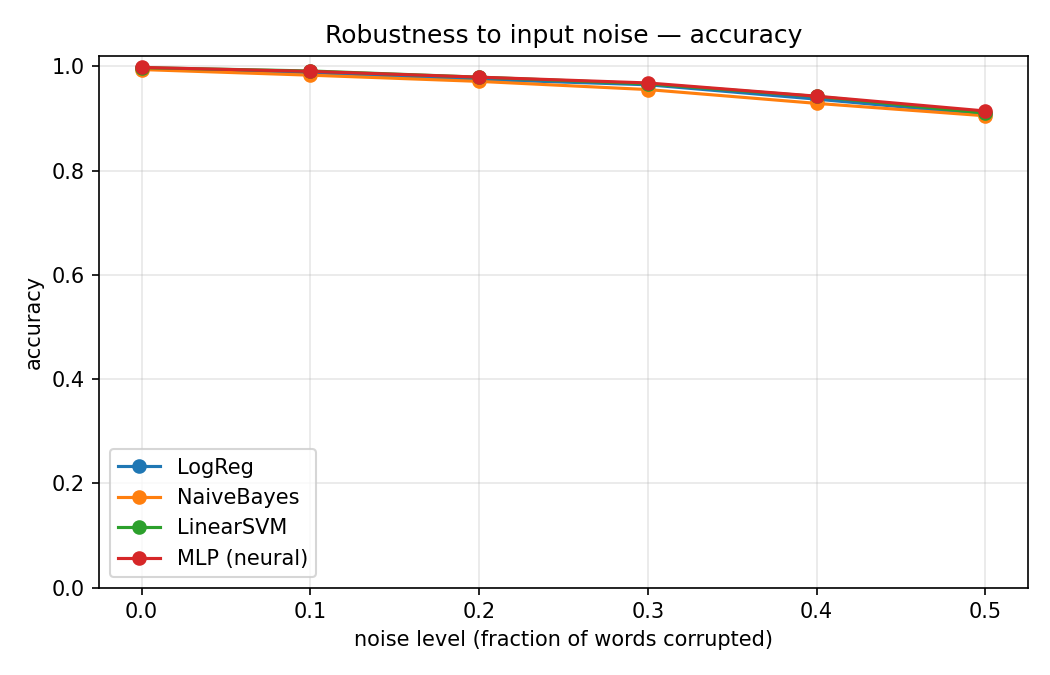

In [4]:
from IPython.display import Image
Image(str(config.FIG_DIR/"robustness_accuracy.png"))

### Interpretation

All evaluated models demonstrate gradual performance degradation as noise levels increase. Even when 50% of the input words are corrupted, classification accuracy remains above 90% across all models.

The neural MLP maintains a slight performance advantage under higher noise levels, although the differences between models remain relatively small. These findings suggest that the classification pipeline is reasonably robust to imperfect customer input and can tolerate substantial text corruption without catastrophic failure.

## 3. Fine-Grained Intent Classification

The earlier experiments grouped customer enquiries into broad categories such as orders, payments, and delivery issues. While useful, these categories may not provide sufficient detail for practical customer service routing.

To explore a more realistic scenario, the classification task was expanded to 27 fine-grained intents covering specific customer requests such as order tracking, account management, refunds, invoice enquiries, and subscription issues..

task         : 27-way intent (fine label)
classes      : 27
accuracy     : 0.99
macro_f1     : 0.9893


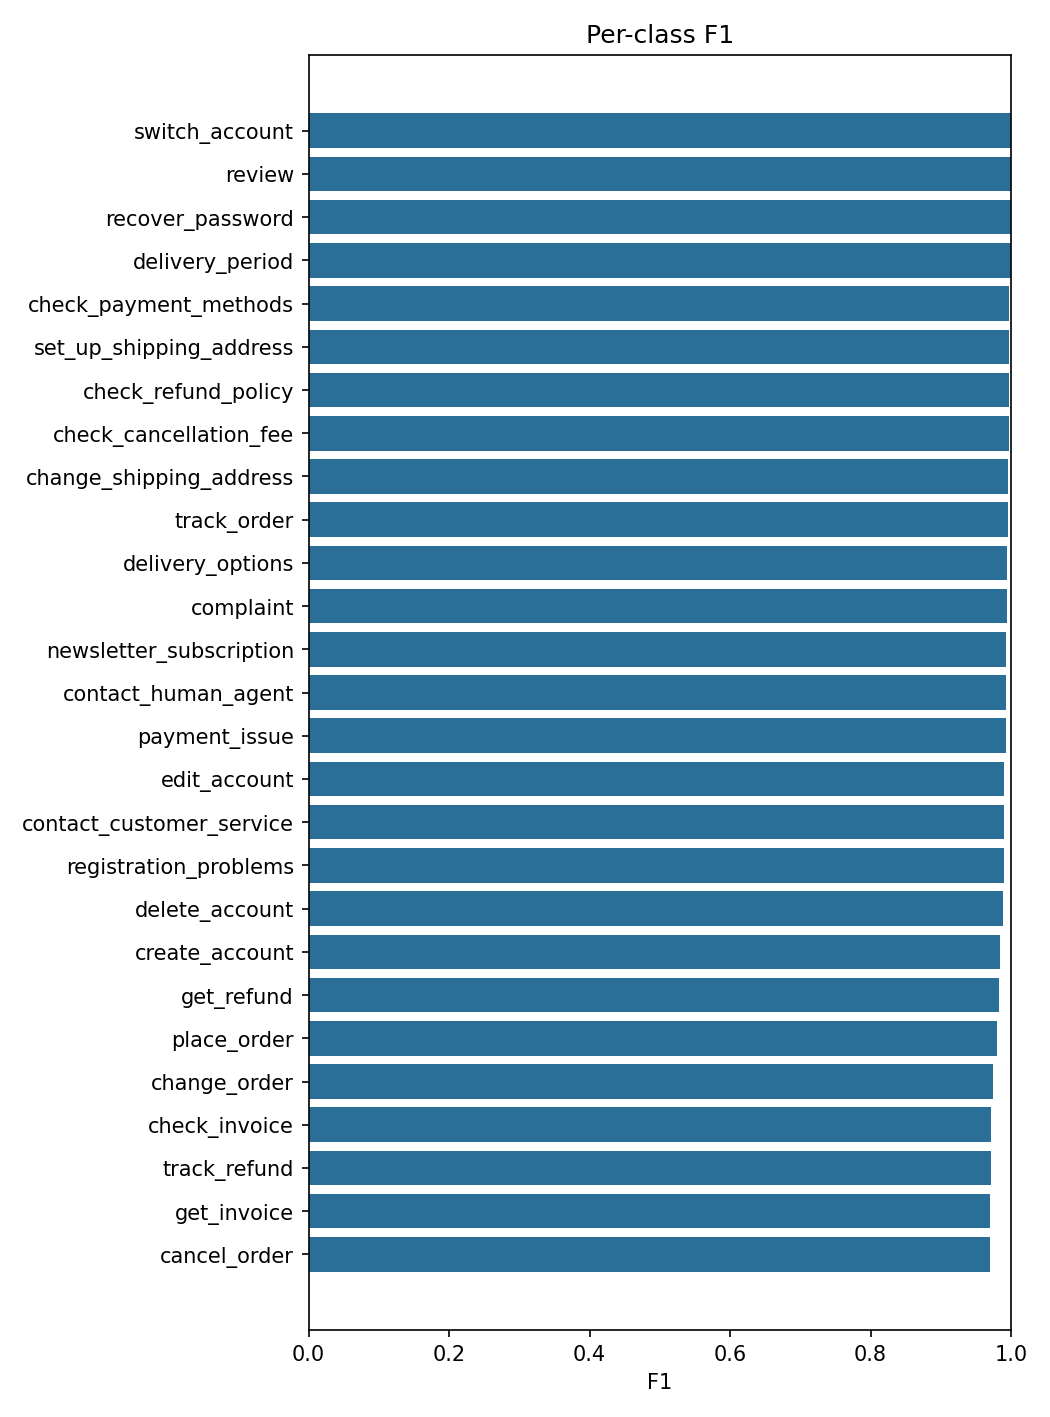

In [5]:
it = json.load(open(config.EVAL_DIR/"intent_27way_metrics.json"))
print(f"task         : {it['task']}")
print(f"classes      : {it['n_classes']}")
print(f"accuracy     : {it['accuracy']}")
print(f"macro_f1     : {it['macro_f1']}")
Image(str(config.FIG_DIR/"intent_per_class_f1.png"))

### Interpretation

Despite the increased complexity of the 27-class problem, the classifier maintains strong overall performance with approximately 99% accuracy and a macro-F1 score close to 0.99.

The per-class F1 scores reveal small variations between intents, providing a more detailed view of system performance than the earlier coarse-grained classification task. This analysis helps identify which customer requests are consistently recognised and which may require additional training data or refinement.

Compared with the broader category classification task, the fine-grained intent setting provides a more realistic assessment of the routing challenges encountered in production customer support systems.

## Discussion

The experiments in this notebook provide further insight into the practical behaviour of the customer service classification system.

The neural network achieves slightly stronger performance than the classical baselines, although the margin is relatively small. This suggests that traditional TF-IDF models remain highly competitive for structured customer support datasets.

The robustness experiments demonstrate that the classification pipeline remains stable even when messages contain significant noise. Finally, the fine-grained intent experiments show that the system can successfully distinguish between a larger set of customer request types while maintaining strong predictive performance.



## Limitations

Several limitations should be considered when interpreting these results.

The Bitext dataset remains relatively structured compared with real customer support conversations. The synthetic noise introduced in the robustness experiments may not fully represent naturally occurring spelling errors and informal language. In addition, the neural network explored in this notebook is a lightweight architecture rather than a large transformer-based model.

Future work could investigate larger language models, real-world customer datasets, and multilingual support scenarios.

## Summary

This notebook explored additional classification experiments beyond the core customer service pipeline.

The experiments included:
- Neural versus classical classifier comparison
- Robustness analysis under noisy input conditions
- Fine-grained 27-way intent classification

The results demonstrate that both classical and neural approaches achieve strong performance, while the robustness and fine-grained intent experiments provide a more realistic assessment of deployment readiness.

Together with the previous notebooks, these findings provide a comprehensive evaluation of the proposed intelligent customer service system.